In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import joblib
import warnings

warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()


Saving archive (14).zip to archive (14).zip


In [4]:
import zipfile
import io
import os

df = None # Initialize df to None

# Assuming the zip file contains a CSV file, let's extract it
for fn in uploaded.keys():
    if fn.endswith('.zip'):
        zip_file = zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r')
        zip_file.extractall('/content/')

        # Search for the CSV file in the extracted directory, including subdirectories
        csv_path = None
        for root, _, files in os.walk('/content/'):
            for name in files:
                if 'customer_churn_data.csv' == name.lower(): # Case-insensitive check for filename
                    csv_path = os.path.join(root, name)
                    break
            if csv_path: # Found the CSV, no need to search further
                break

        if csv_path:
            print(f"Found CSV at: {csv_path}")
            df = pd.read_csv(csv_path)
            break # Exit the loop after processing the first zip
        else:
            print("No 'customer_churn_data.csv' found after extraction in /content/ or its subdirectories.")

if df is not None:
    print("DataFrame loaded successfully.")
    df.head()
else:
    print("Error: DataFrame 'df' could not be loaded. Please check the zip file contents and CSV name.")

Found CSV at: /content/customer_churn_data.csv
DataFrame loaded successfully.


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (5880, 21)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


In [7]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,5880,5880,5880.000000,5880,5880,5880.000000,5880,5880,5880,5880,...,5880,5880,5880,5880,5880,5880,5880,5880.000000,5880.000000,5880
unique,5880,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,CUST5879,Male,NaN,Yes,No,NaN,Yes,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,NaN,NaN,No
freq,1,2950,NaN,2995,3004,NaN,2941,2939,2029,2029,...,2029,2029,2029,2029,2020,2990,1503,NaN,NaN,2982
mean,NaN,NaN,0.500680,NaN,NaN,36.549150,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.157779,2566.813165,NaN
std,NaN,NaN,0.500042,NaN,NaN,20.909674,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.804615,1910.017743,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,20.030000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.717500,1020.217500,NaN
50%,NaN,NaN,1.000000,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.155000,2136.445000,NaN
75%,NaN,NaN,1.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.457500,3767.665000,NaN


In [8]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
print(df["Churn"].value_counts())

Churn
No     2982
Yes    2898
Name: count, dtype: int64


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
print("Blank values in TotalCharges:",
      (df["TotalCharges"] == " ").sum())

Blank values in TotalCharges: 0


In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [15]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [16]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,23,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,Female,0,Yes,No,43,No,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,Male,1,No,No,51,Yes,No,DSL,No,Yes,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,Male,1,No,No,72,Yes,Yes,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,Male,1,No,No,25,Yes,Yes,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


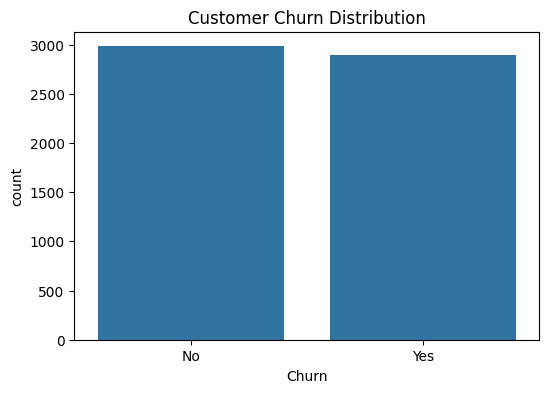

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [18]:
print(
    df["Churn"].value_counts(normalize=True) * 100
)

Churn
No     50.714286
Yes    49.285714
Name: proportion, dtype: float64


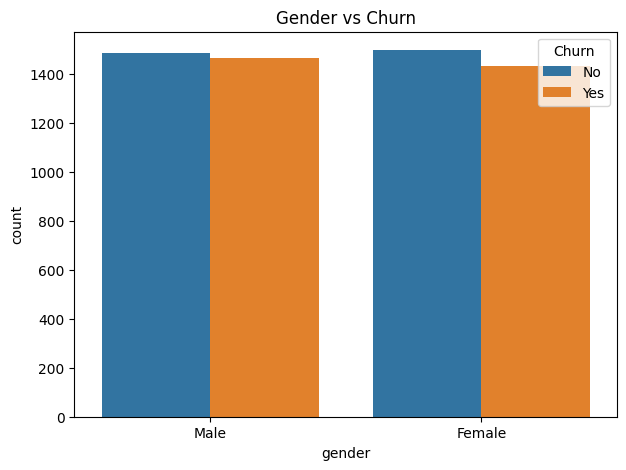

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")
plt.show()

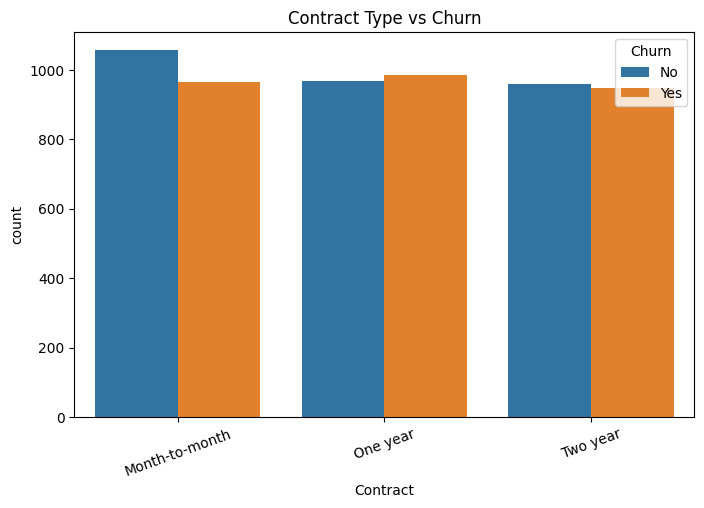

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)

plt.title("Contract Type vs Churn")
plt.show()

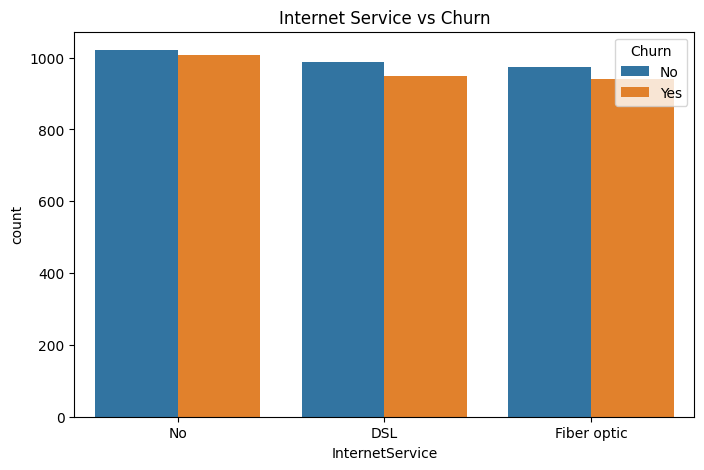

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

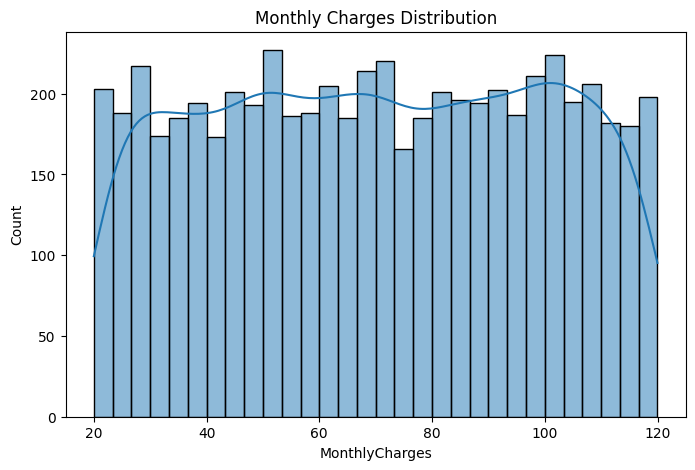

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

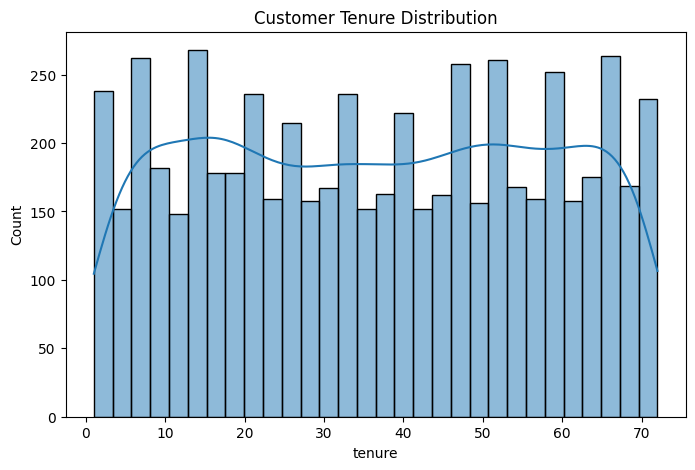

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.show()

In [24]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [25]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, "Outliers:", len(outliers))

tenure Outliers: 0
MonthlyCharges Outliers: 0
TotalCharges Outliers: 32


In [26]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

In [27]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [28]:
df["Churn"].value_counts()

,count
Churn,
0,2982
1,2898


In [29]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Short", "Medium", "Long"]
)

In [31]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [33]:
selected_columns = [
    "tenure",
    "TotalCharges",
    "AvgMonthlySpend",
    "TenureGroup"
]
df[selected_columns].head()

,tenure,TotalCharges,AvgMonthlySpend,TenureGroup
0,23,1146.55,47.772917,Short
1,43,4330.10,98.411364,Medium
2,51,4963.83,95.458269,Long
3,72,7299.36,99.991233,Long
4,25,1305.50,50.211538,Medium


In [34]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [35]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Short,TenureGroup_Medium,TenureGroup_Long
0,0,23,49.85,1146.55,0,47.772917,True,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,0,43,100.70,4330.10,1,98.411364,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,1,51,97.33,4963.83,1,95.458269,True,False,False,True,...,False,True,False,False,False,True,False,False,False,True
3,1,72,101.38,7299.36,0,99.991233,True,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,1,25,52.22,1305.50,1,50.211538,True,False,False,True,...,True,False,False,False,False,True,False,False,True,False


In [36]:
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

In [37]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5880, 34)
y shape: (5880,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4704, 34)
Testing data: (1176, 34)


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [40]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

In [41]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(
    X_test_scaled
)

In [42]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [44]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [45]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_test,
        knn_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

In [46]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.486395,0.476000,0.410345,0.440741
1,KNN,0.499150,0.491950,0.474138,0.482880
2,Decision Tree,0.503401,0.497802,0.781034,0.608054
3,Random Forest,0.477891,0.468519,0.436207,0.451786


In [47]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Decision Tree,0.503401,0.497802,0.781034,0.608054
1,KNN,0.499150,0.491950,0.474138,0.482880
3,Random Forest,0.477891,0.468519,0.436207,0.451786
0,Logistic Regression,0.486395,0.476000,0.410345,0.440741


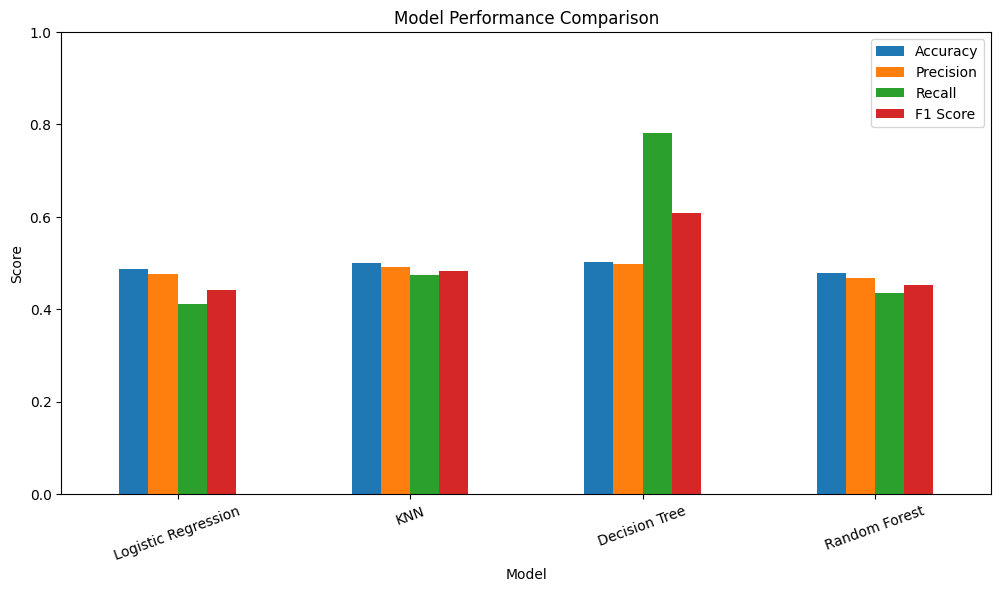

In [48]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

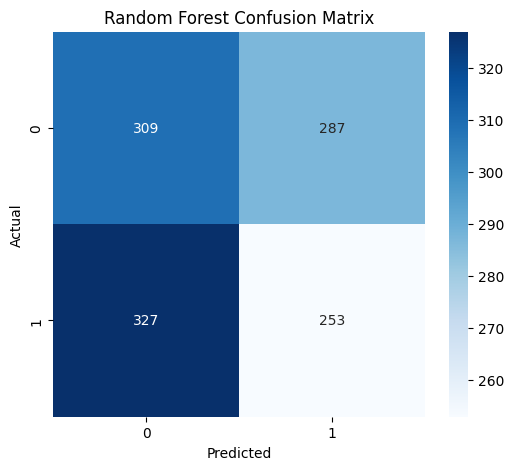

In [49]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [50]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.49      0.52      0.50       596
           1       0.47      0.44      0.45       580

    accuracy                           0.48      1176
   macro avg       0.48      0.48      0.48      1176
weighted avg       0.48      0.48      0.48      1176



In [51]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [52]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

In [53]:
grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

In [54]:
grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [55]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}


In [56]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        tuned_pred
    )
)

              precision    recall  f1-score   support

           0       0.49      0.52      0.51       596
           1       0.48      0.46      0.47       580

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



In [57]:
joblib.dump(
    best_model,
    "churn_model.pkl"
)

['churn_model.pkl']

In [58]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [59]:
joblib.dump(
    list(X.columns),
    "feature_names.pkl"
)

['feature_names.pkl']

In [60]:
import os

print(os.listdir())

['.config', 'archive (14).zip', 'customer_churn_data.csv', 'churn_model.pkl', 'feature_names.pkl', 'scaler.pkl', 'sample_data']
